## Forecast

** This file makes a sample forecast based on the data: the monthly profit for a sample of 12 months

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import(mean_absolute_error,
    mean_squared_error)

In [2]:
## loading data set

data = pd.read_csv("../data_folder/Feature_engineered_data.csv")
data.head(2)

,Order_Date,Year,Month,Quarter,Season,Customer_ID,Customer_Gender,Customer_Segment,Region,Country,...,Shipping_Days,Payment_Method,Order_Status,Order_Month,Order_Quarter,Order_Year,revenue_per_unit,profit_per_unit,scost_per_revenue,net_revenue
0,2021-01-05,2021,January,Q1,Winter,CUST-02274,Female,New,Asia,India,...,22,Cash on Delivery,Delivered,1,1,2021,56.095,-9.050,0.162849,6.140668
1,2021-01-15,2021,January,Q1,Winter,CUST-04879,Female,Premium,Middle East,Jordan,...,18,Credit Card,Delivered,1,1,2021,465.790,30.555,0.039857,25.089685


In [3]:
## converting date column

data["Order_Date"] = pd.to_datetime(data["Order_Date"])

In [4]:
## grouping orders by month

monthly_profit = (
    data.groupby(pd.Grouper(key="Order_Date", freq="ME"))["Profit"].sum().reset_index()
)

In [5]:
monthly_profit.head(10)

,Order_Date,Profit
0,2021-01-31,3967.15
1,2021-02-28,2310.85
2,2021-03-31,1914.07
3,2021-04-30,4227.08
4,2021-05-31,7687.58
5,2021-06-30,7524.44
6,2021-07-31,9524.55
7,2021-08-31,23982.27
8,2021-09-30,14508.57
9,2021-10-31,23840.24


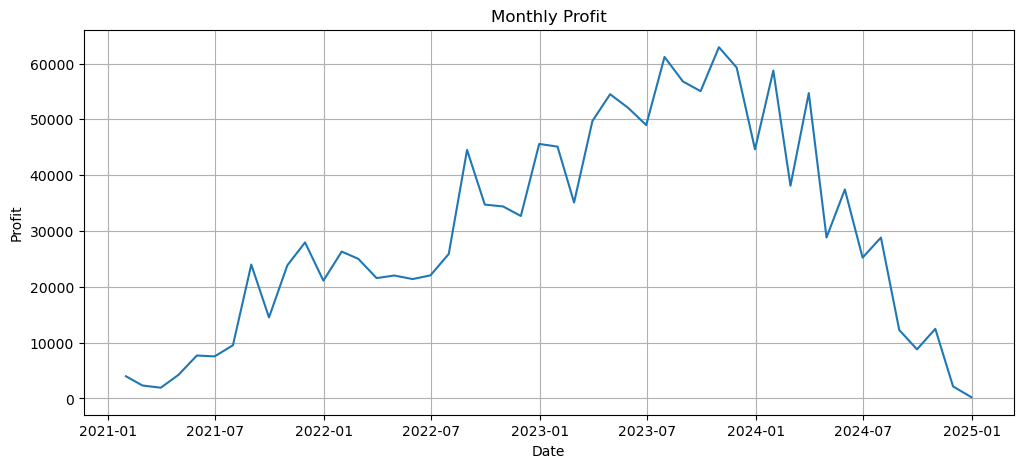

In [6]:
## plotting a time series

plt.figure(figsize=(12,5))
plt.plot(monthly_profit["Order_Date"],
        monthly_profit["Profit"])

plt.title("Monthly Profit")
plt.xlabel("Date")
plt.ylabel("Profit")
plt.grid(True)
plt.show()
           

In [7]:
monthly_profit.set_index("Order_Date", inplace=True)

In [8]:
## split into train and test set

train = monthly_profit[:-6]
test = monthly_profit[-6:]

In [9]:
## training the model
model = ARIMA(train, order = (2,1,2))
model_fit = model.fit()

C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


In [10]:
forecast = model_fit.forecast(steps=6)

In [11]:
forecast

2024-07-31    28067.240308
2024-08-31    23192.057454
2024-09-30    21689.921753
2024-10-31    20528.570940
2024-11-30    19906.016432
2024-12-31    19529.040301
Freq: ME, Name: predicted_mean, dtype: float64

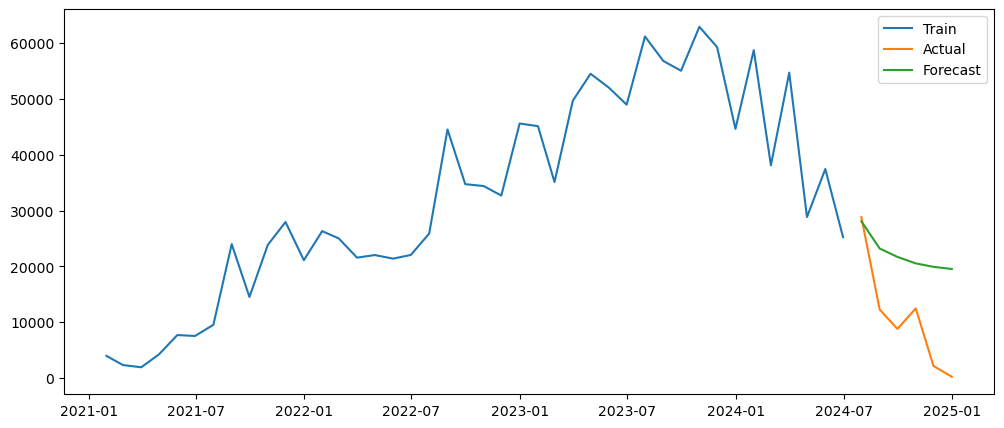

In [12]:
## plot forcast vs actual


plt.figure(figsize=(12, 5))

plt.plot(train.index, train["Profit"], label= "Train")
plt.plot(test.index, test["Profit"], label="Actual")
plt.plot(test.index, forecast, label="Forecast")

plt.legend()
plt.show()

In [13]:
## evaluation

mae = mean_absolute_error(test["Profit"], forecast)

rmse = np.sqrt(mean_squared_error(test["Profit"], forecast))

print(mae)
print(rmse)

11621.19109531362
13166.787154962729


In [14]:
## forecast future month

final_model = ARIMA(monthly_profit, order=(2,1,2)).fit()

C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


In [15]:
future = final_model.forecast(steps = 12)

In [16]:
## testing with future dates

future_dates = pd.date_range(
    start = monthly_profit.index[-1] + pd.offsets.MonthEnd(),
    periods = 12,
    freq = "ME"
)

In [17]:
forecast_dataframe = pd.DataFrame({
    "Date": future_dates,
    "Forecasted_Profit": future
})

In [18]:
future_dates


DatetimeIndex(['2025-01-31', '2025-02-28', '2025-03-31', '2025-04-30',
               '2025-05-31', '2025-06-30', '2025-07-31', '2025-08-31',
               '2025-09-30', '2025-10-31', '2025-11-30', '2025-12-31'],
              dtype='datetime64[ns]', freq='ME')

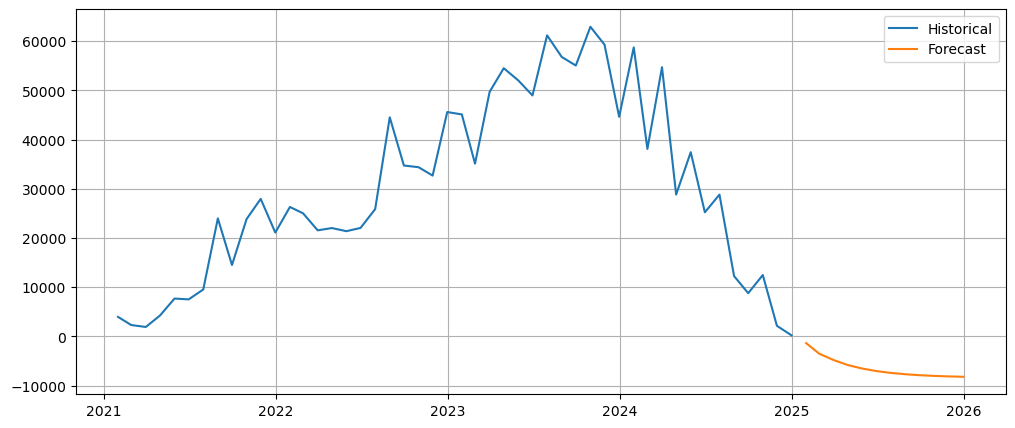

In [19]:
## plotting final forecast

plt.figure(figsize = (12, 5))

plt.plot(
    monthly_profit.index,
    monthly_profit["Profit"],
    label = "Historical"
)

plt.plot(forecast_dataframe["Date"],
        forecast_dataframe["Forecasted_Profit"],
        label="Forecast")

plt.legend()
plt.grid(True)
plt.show()

In [20]:
forecast_dataframe.to_csv(
    "Profit_Forecast.csv",
    index=False
)